In [2]:
# Operating system and file management
import os

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Classification models
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
os.getcwd()
os.chdir(r"C:\Users\ANWAR\Desktop\Intership")

In [4]:
os.getcwd()
os.listdir()

['DATA SCIENCE TASK LIST.pdf', 'Dataset.csv', 'Netflix_cleaned.csv']

In [5]:
#Import DataSet 

df = pd.read_csv("Dataset.csv")

df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
# Data SetSize
df.shape

(8790, 10)

In [7]:
# Column name 
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [8]:
#Data Type and missing value 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [9]:
# statistical summary 
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [10]:
# identify missing value 
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [11]:
# interpretation 
#That means there are no missing/null values in any of the 10 columns.

In [12]:
# identify duplicate
df.duplicated().sum()


np.int64(0)

In [13]:
# interpretation 
#There are 0 completely duplicated rows.

In [14]:
# Check unique values in categorical columns
df["type"].unique()


array(['Movie', 'TV Show'], dtype=object)

In [15]:
df["rating"].unique()

array(['PG-13', 'TV-MA', 'TV-PG', 'TV-14', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'R', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [16]:
df["duration"].head(20)

0        90 min
1      1 Season
2      1 Season
3        91 min
4       125 min
5     9 Seasons
6       104 min
7        87 min
8       127 min
9        76 min
10       76 min
11       71 min
12      131 min
13       39 min
14       36 min
15       34 min
16       35 min
17     1 Season
18     1 Season
19       46 min
Name: duration, dtype: object

In [17]:
# Check date format
df["date_added"].head(10)

0    9/25/2021
1    9/24/2021
2    9/24/2021
3    9/22/2021
4    9/24/2021
5    9/24/2021
6    9/24/2021
7     5/1/2021
8    9/23/2021
9     5/1/2021
Name: date_added, dtype: object

In [18]:
# Transform date_added 
df["date_added"] = pd.to_datetime(df["date_added"])

df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-22
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [19]:
# check date type
df["date_added"].dtype

dtype('<M8[ns]')

In [20]:
# Transform duration
df["duration_minutes"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0].where(df["duration"].str.contains("min")),
    errors="coerce"
)

df["duration_seasons"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0].where(df["duration"].str.contains("Season")),
    errors="coerce"
)

df[["duration", "duration_minutes", "duration_seasons"]].head(20)

,duration,duration_minutes,duration_seasons
0,90 min,90.0,NaN
1,1 Season,NaN,1.0
2,1 Season,NaN,1.0
3,91 min,91.0,NaN
4,125 min,125.0,NaN
5,9 Seasons,NaN,9.0
6,104 min,104.0,NaN
7,87 min,87.0,NaN
8,127 min,127.0,NaN
9,76 min,76.0,NaN


In [21]:
df["duration"].isnull().sum()

np.int64(0)

In [22]:
df[["duration_minutes", "duration_seasons"]].isnull().sum()

duration_minutes    2664
duration_seasons    6126
dtype: int64

In [23]:
# Extract year and month
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month
df["added_month_name"] = df["date_added"].dt.month_name()

In [24]:
# Check categorical columns
df["rating"].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

In [25]:
df["type"].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [26]:
# Check text formatting 
text_columns = ["title", "director", "country", "rating", "listed_in"]

for column in text_columns:
    df[column] = df[column].str.strip()

In [27]:
# Final dataset inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8790 non-null   object        
 1   type              8790 non-null   object        
 2   title             8790 non-null   object        
 3   director          8790 non-null   object        
 4   country           8790 non-null   object        
 5   date_added        8790 non-null   datetime64[ns]
 6   release_year      8790 non-null   int64         
 7   rating            8790 non-null   object        
 8   duration          8790 non-null   object        
 9   listed_in         8790 non-null   object        
 10  duration_minutes  6126 non-null   float64       
 11  duration_seasons  2664 non-null   float64       
 12  added_year        8790 non-null   int32         
 13  added_month       8790 non-null   int32         
 14  added_month_name  8790 n

In [28]:
# check final structure 
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_minutes,duration_seasons,added_year,added_month,added_month_name
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90.0,NaN,2021,9,September
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",NaN,1.0,2021,9,September
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",NaN,1.0,2021,9,September
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91.0,NaN,2021,9,September
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125.0,NaN,2021,9,September


In [29]:
# Save the clean dataset
df.to_csv("Netflix_cleaned.csv", index=False)

In [30]:
# confirm file existing 
os.listdir()

['DATA SCIENCE TASK LIST.pdf', 'Dataset.csv', 'Netflix_cleaned.csv']

In [31]:
# Content distribution by type

type_counts = df["type"].value_counts()

type_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [32]:
# Calculate percentages
type_percentage = df["type"].value_counts(normalize=True) * 100

type_percentage

type
Movie      69.692833
TV Show    30.307167
Name: proportion, dtype: float64

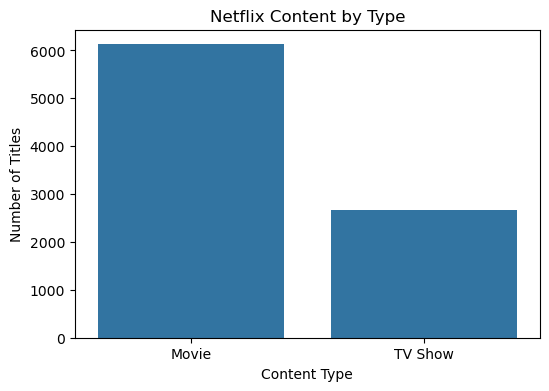

In [33]:
# Visualize content type
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="type")

plt.title("Netflix Content by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

In [34]:
# Find top countries
df["country"].value_counts()

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Iran                 1
West Germany         1
Greece               1
Zimbabwe             1
Soviet Union         1
Name: count, Length: 86, dtype: int64

In [35]:
# separate usa and canada
countries = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

countries.head(10)

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

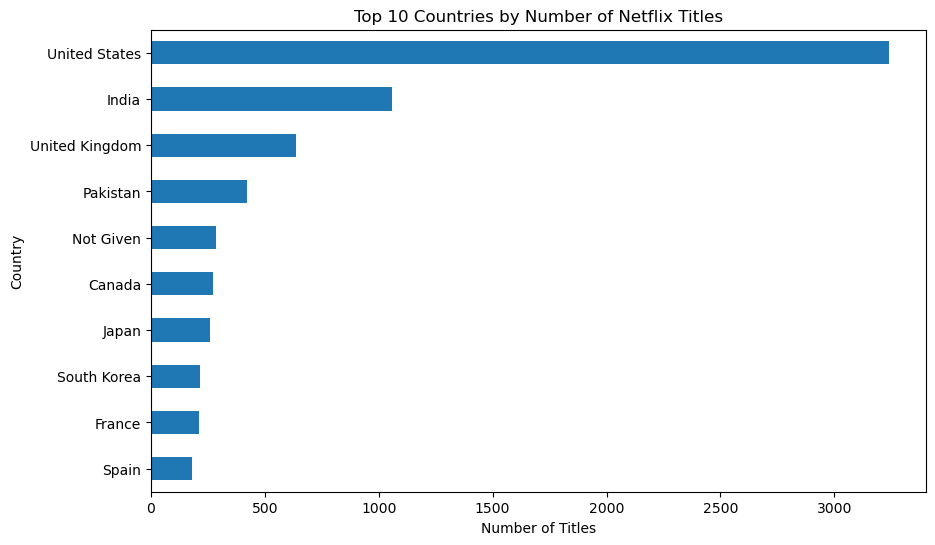

In [36]:
# Visualize top 10 countries
plt.figure(figsize=(10, 6))

countries.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

In [37]:
# Find top categories
categories = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

categories.head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [38]:
# Content by release year
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

release_year
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

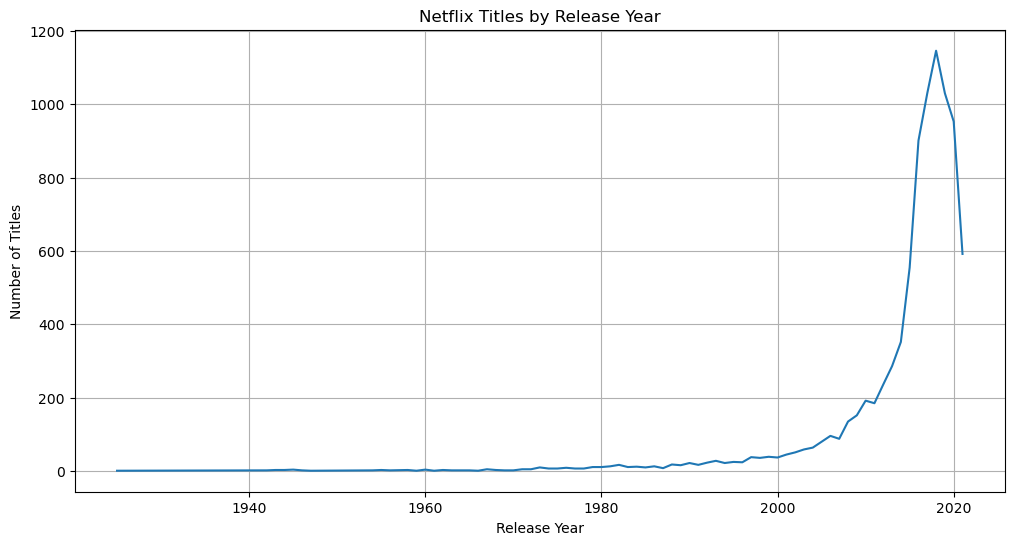

In [39]:
# Visualize release-year trend
plt.figure(figsize=(12, 6))

release_year_counts.plot()

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True)
plt.show()

In [40]:
# Content added to Netflix by year
added_year_counts = df["added_year"].value_counts().sort_index()

added_year_counts

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

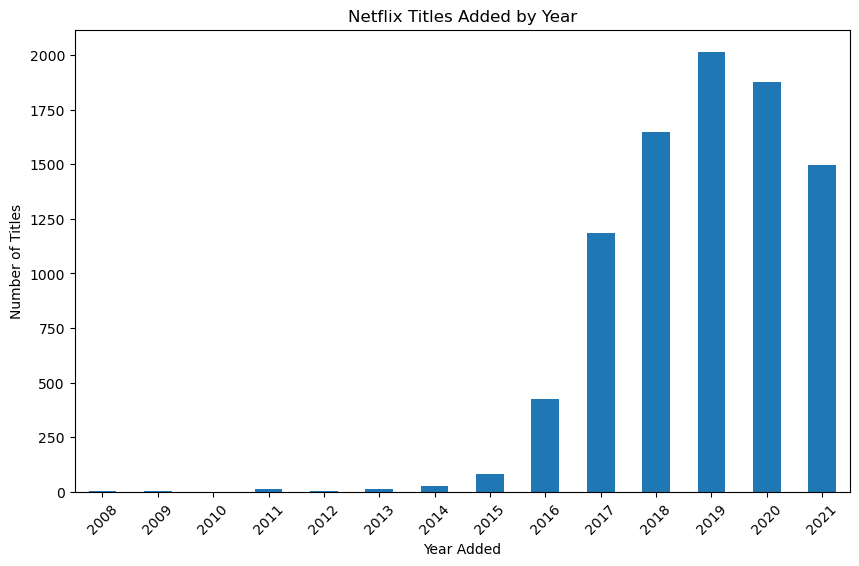

In [41]:
plt.figure(figsize=(10, 6))

added_year_counts.plot(kind="bar")

plt.title("Netflix Titles Added by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [42]:
#Ratings Analysis
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

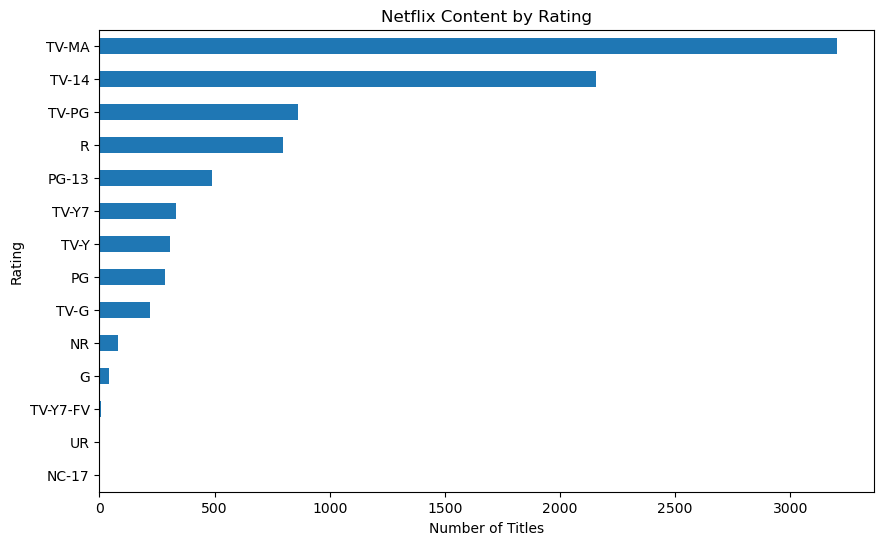

In [43]:
# Visualize ratings
plt.figure(figsize=(10, 6))

rating_counts.sort_values().plot(kind="barh")

plt.title("Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [44]:
# Movie vs TV Show comparison
content_rating = pd.crosstab(df["rating"], df["type"])

content_rating

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,730
TV-G,126,94
TV-MA,2062,1143


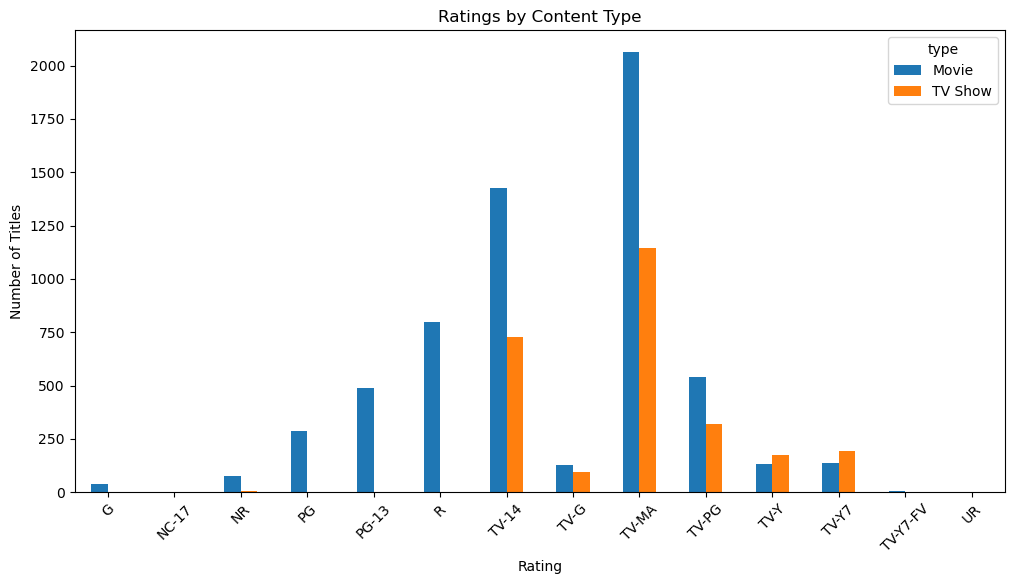

In [45]:
content_rating.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [46]:
#Release Year
#Number of titles by release year
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

release_year
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

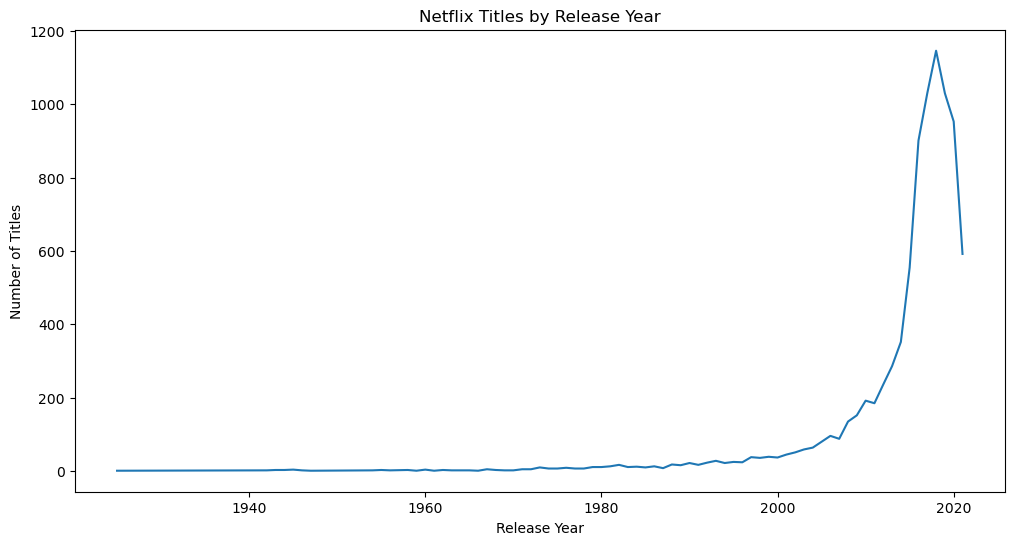

In [47]:
# Plot release-year trend
plt.figure(figsize=(12, 6))

release_year_counts.plot()

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [48]:
# Movie duration
movie_duration = df.loc[
    df["type"] == "Movie",
    "duration_minutes"
]

movie_duration.describe()

count    6126.000000
mean       99.584884
std        28.283225
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

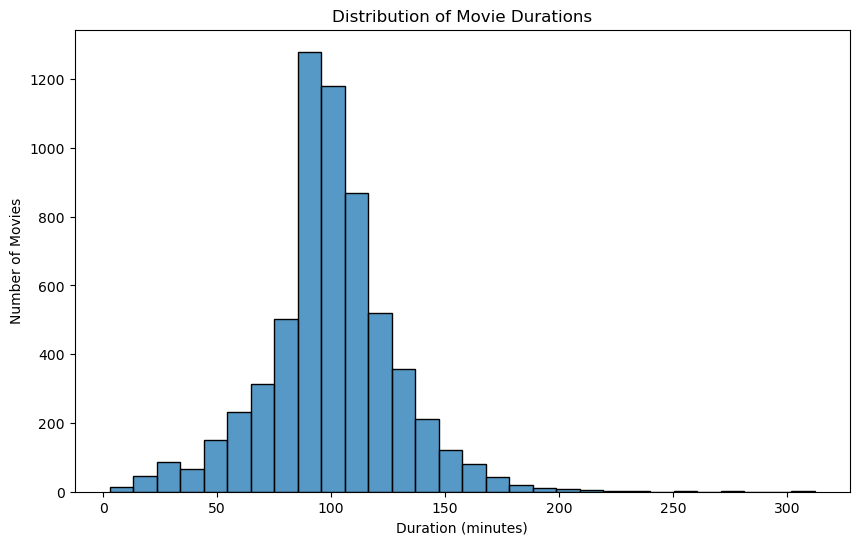

In [49]:
# Movie duration distribution
plt.figure(figsize=(10, 6))

sns.histplot(movie_duration.dropna(), bins=30)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [50]:
# Release Year
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

release_year
2002      51
2003      59
2004      64
2005      80
2006      96
2007      88
2008     135
2009     152
2010     192
2011     185
2012     236
2013     286
2014     352
2015     555
2016     901
2017    1030
2018    1146
2019    1030
2020     953
2021     592
Name: count, dtype: int64

In [51]:
# Choose features for recommendation
# Create a combined feature for recommendation

df["content_features"] = (
    df["type"].fillna("") + " " +
    df["director"].fillna("") + " " +
    df["country"].fillna("") + " " +
    df["listed_in"].fillna("") + " " +
    df["rating"].fillna("")
)

df[["title", "content_features"]].head()

,title,content_features
0,Dick Johnson Is Dead,Movie Kirsten Johnson United States Documentar...
1,Ganglands,"TV Show Julien Leclercq France Crime TV Shows,..."
2,Midnight Mass,"TV Show Mike Flanagan United States TV Dramas,..."
3,Confessions of an Invisible Girl,Movie Bruno Garotti Brazil Children & Family M...
4,Sankofa,"Movie Haile Gerima United States Dramas, Indep..."


In [52]:
# Convert text into numbers using TF-IDF 
# Convert content features into numerical TF-IDF vectors

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["content_features"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (8790, 6569)


In [53]:
# Calculate content similarity
# Calculate similarity between all Netflix titles

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine similarity matrix shape:", cosine_sim.shape)

Cosine similarity matrix shape: (8790, 8790)


In [54]:
#Generate recommendations
def recommend_titles(title, num_recommendations=10):
    # Find the index of the selected title
    title_index = df[df["title"].str.lower() == title.lower()].index[0]

    # Get similarity scores for that title
    similarity_scores = list(enumerate(cosine_sim[title_index]))

    # Sort from most similar to least similar
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected title itself and get top recommendations
    top_recommendations = similarity_scores[1:num_recommendations + 1]

    # Get the title names
    recommendations = [
        df.iloc[index]["title"]
        for index, score in top_recommendations
    ]

    return recommendations

In [55]:
recommend_titles("Sankofa")

['Residue',
 "BoJack Horseman Christmas Special: Sabrina's Christmas Wish",
 'The Darkest Dawn',
 'Adhugo',
 '100 Things to do Before High School',
 'Pocoyo Halloween: Space Halloween',
 'Manson Family Vacation',
 'Seven (Tamil)',
 'Taramani',
 'Yeh Hai Bakrapur']

In [56]:
#Check recommendation scores
def recommend_titles_with_scores(title, num_recommendations=10):
    # Find the selected title
    title_index = df[df["title"].str.lower() == title.lower()].index[0]

    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[title_index]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected title
    top_recommendations = similarity_scores[1:num_recommendations + 1]

    # Return title and similarity score
    return pd.DataFrame(
        [
            {
                "Title": df.iloc[index]["title"],
                "Similarity": round(score, 3)
            }
            for index, score in top_recommendations
        ]
    )

In [57]:
recommend_titles_with_scores("Sankofa")

,Title,Similarity
0,Residue,0.562
1,BoJack Horseman Christmas Special: Sabrina's C...,0.295
2,The Darkest Dawn,0.292
3,Adhugo,0.272
4,100 Things to do Before High School,0.262
5,Pocoyo Halloween: Space Halloween,0.262
6,Manson Family Vacation,0.253
7,Seven (Tamil),0.248
8,Taramani,0.246
9,Yeh Hai Bakrapur,0.243


In [58]:
# prepare the trend data
# Prepare yearly content data for trend analysis

trend_data = (
    df.groupby("added_year")
      .size()
      .reset_index(name="title_count")
)

trend_data


,added_year,title_count
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,426
9,2017,1185


In [60]:
# Prepare data for prediction
from sklearn.linear_model import LinearRegression
# Prepare features and target for trend prediction

X_trend = trend_data[["added_year"]]
y_trend = trend_data["title_count"]

print("X shape:", X_trend.shape)
print("y shape:", y_trend.shape)

X shape: (14, 1)
y shape: (14,)


In [61]:
# Train the Linear Regression model 
# Create and train the linear regression model
trend_model = LinearRegression()

trend_model.fit(X_trend, y_trend)

print("Model trained successfully.")
print("Slope:", trend_model.coef_[0])
print("Intercept:", trend_model.intercept_)

Model trained successfully.
Slope: 168.9846153846154
Intercept: -339791.6505494506


In [62]:
# interpretation 
# For every 1-year increase, the model predicts about 169 more titles addedon average

In [63]:
# Predict title counts for the existing years
y_pred = trend_model.predict(X_trend)

trend_data["predicted_count"] = y_pred.round(0).astype(int)

trend_data

,added_year,title_count,predicted_count
0,2008,2,-471
1,2009,2,-302
2,2010,1,-133
3,2011,13,36
4,2012,3,205
5,2013,11,374
6,2014,24,543
7,2015,82,712
8,2016,426,881
9,2017,1185,1050


In [65]:
# Evaluate the model 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Evaluate the trend prediction model
mae = mean_absolute_error(y_trend, y_pred)
rmse = np.sqrt(mean_squared_error(y_trend, y_pred))
r2 = r2_score(y_trend, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 346.07
RMSE: 390.31
R²: 0.75


In [66]:
# interpretation 
# MAE = 346.07 → predictions are off by about 346 titles on average.
# RMSE = 390.31 → larger prediction errors exist, especially around the years where the number of titles changed sharply.
# R² = 0.75 → the model explains about 75% of the variation in the historical title-count trend.

In [68]:
# Predict future trends 
# Predict future title additions
future_years = pd.DataFrame({
    "added_year": [2022, 2023, 2024, 2025]
})

future_predictions = trend_model.predict(future_years)

future_trend = future_years.copy()
future_trend["predicted_count"] = future_predictions.round(0).astype(int)

future_trend

,added_year,predicted_count
0,2022,1895
1,2023,2064
2,2024,2233
3,2025,2402


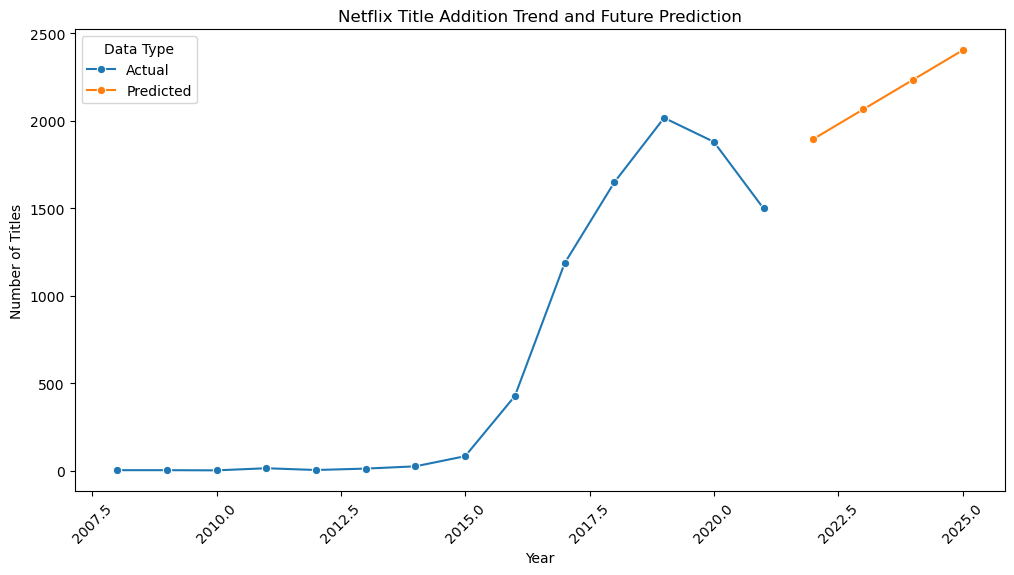

In [69]:
# visualization 
# Combine historical and future data
historical_plot = trend_data[["added_year", "title_count"]].copy()
historical_plot["data_type"] = "Actual"

future_plot = future_trend.rename(
    columns={"predicted_count": "title_count"}
)[["added_year", "title_count"]].copy()
future_plot["data_type"] = "Predicted"

plot_data = pd.concat([historical_plot, future_plot])

# Plot actual and predicted trends
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=plot_data,
    x="added_year",
    y="title_count",
    hue="data_type",
    marker="o"
)

plt.title("Netflix Title Addition Trend and Future Prediction")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Data Type")
plt.show()

In [70]:
# ML Classification Model 


In [71]:
# Select features for classification
X = df[
    [
        "release_year",
        "rating",
        "duration_minutes",
        "duration_seasons",
        "added_year",
        "added_month"
    ]
].copy()

# Target variable
y = df["type"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (8790, 6)
Target shape: (8790,)


In [72]:
# Convert the categorical rating column into numerical columns
X = pd.get_dummies(
    X,
    columns=["rating"],
    drop_first=True
)

print("New features shape:", X.shape)
print(X.head())

New features shape: (8790, 18)
   release_year  duration_minutes  duration_seasons  added_year  added_month  \
0          2020              90.0               NaN        2021            9   
1          2021               NaN               1.0        2021            9   
2          2021               NaN               1.0        2021            9   
3          2021              91.0               NaN        2021            9   
4          1993             125.0               NaN        2021            9   

   rating_NC-17  rating_NR  rating_PG  rating_PG-13  rating_R  rating_TV-14  \
0         False      False      False          True     False         False   
1         False      False      False         False     False         False   
2         False      False      False         False     False         False   
3         False      False      False         False     False         False   
4         False      False      False         False     False         False   

   rating_TV-

In [73]:
# Fill missing numerical values with 0
X = X.fillna(0)

# Convert True/False values to 1/0
X = X.astype(int)

# Convert target labels into numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Features shape:", X.shape)
print("Target shape:", y_encoded.shape)
print("Classes:", label_encoder.classes_)

Features shape: (8790, 18)
Target shape: (8790,)
Classes: ['Movie' 'TV Show']


In [74]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (7032, 18)
Testing features: (1758, 18)
Training labels: (7032,)
Testing labels: (1758,)


In [75]:
# Create and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [76]:
# Make predictions on the test data
y_pred_logistic = logistic_model.predict(X_test)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_logistic))

Predictions completed.
Number of predictions: 1758


In [77]:
# Evaluate Logistic Regression
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Performance")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


Logistic Regression Performance
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [78]:
# Remove the leakage features 
# Remove features that directly reveal the content type
X_clean = X.drop(
    columns=["duration_minutes", "duration_seasons"]
)

print("Clean features shape:", X_clean.shape)
print(X_clean.head())

Clean features shape: (8790, 16)
   release_year  added_year  added_month  rating_NC-17  rating_NR  rating_PG  \
0          2020        2021            9             0          0          0   
1          2021        2021            9             0          0          0   
2          2021        2021            9             0          0          0   
3          2021        2021            9             0          0          0   
4          1993        2021            9             0          0          0   

   rating_PG-13  rating_R  rating_TV-14  rating_TV-G  rating_TV-MA  \
0             1         0             0            0             0   
1             0         0             0            0             1   
2             0         0             0            0             1   
3             0         0             0            0             0   
4             0         0             0            0             1   

   rating_TV-PG  rating_TV-Y  rating_TV-Y7  rating_TV-Y7-FV  rati

In [79]:
# Split the clean features into training and testing sets
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train_clean.shape)
print("Testing features:", X_test_clean.shape)

Training features: (7032, 16)
Testing features: (1758, 16)


In [83]:
# Training features: (7032, 16) 
# Train Logistic Regression using the clean features
logistic_model_clean = LogisticRegression(max_iter=1000)

logistic_model_clean.fit(X_train_clean, y_train_clean)

print("Clean Logistic Regression model trained successfully.")

Clean Logistic Regression model trained successfully.


C:\Users\ANWAR\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [84]:
# Fix convergence with feature scaling 
from sklearn.preprocessing import StandardScaler
# Scale the clean features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Feature scaling completed.")

Feature scaling completed.


In [85]:
# Retrain Logistic Regression using scaled features
logistic_model_clean = LogisticRegression(max_iter=1000)

logistic_model_clean.fit(X_train_scaled, y_train_clean)

print("Scaled Logistic Regression model trained successfully.")

Scaled Logistic Regression model trained successfully.


In [86]:
# Make predictions 
y_pred_logistic_clean = logistic_model_clean.predict(X_test_scaled)

print("Predictions completed.")
print("Number of predictions:", len(y_pred_logistic_clean))

Predictions completed.
Number of predictions: 1758


In [87]:
# Evaluate Logistic Regression 
accuracy = accuracy_score(y_test_clean, y_pred_logistic_clean)
precision = precision_score(y_test_clean, y_pred_logistic_clean)
recall = recall_score(y_test_clean, y_pred_logistic_clean)
f1 = f1_score(y_test_clean, y_pred_logistic_clean)

print("Logistic Regression Performance")
print("Accuracy :", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall   :", round(recall, 3))
print("F1-Score :", round(f1, 3))

Logistic Regression Performance
Accuracy : 0.706
Precision: 0.583
Recall   : 0.105
F1-Score : 0.178


In [88]:
# interpretation 
# Metric	Score	Simple meaning
# Accuracy	70.6%	Overall, 70.6% of predictions were correct
# Precision	58.3%	When model predicts TV Show, 58.3% are actually TV Shows
# Recall	10.5%	Model finds only 10.5% of the actual TV Shows
# F1-score	17.8%	Overall balance of precision and recall is weak

In [89]:
# Decision Tree 
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train_clean,
    y_train_clean
)

y_pred_tree = decision_tree_model.predict(X_test_clean)

print("Decision Tree model trained and predictions completed.")

Decision Tree model trained and predictions completed.


In [90]:
# Evaluate Decision Tree 
accuracy_tree = accuracy_score(y_test_clean, y_pred_tree)
precision_tree = precision_score(y_test_clean, y_pred_tree)
recall_tree = recall_score(y_test_clean, y_pred_tree)
f1_tree = f1_score(y_test_clean, y_pred_tree)

print("Decision Tree Performance")
print("Accuracy :", round(accuracy_tree, 3))
print("Precision:", round(precision_tree, 3))
print("Recall   :", round(recall_tree, 3))
print("F1-Score :", round(f1_tree, 3))

Decision Tree Performance
Accuracy : 0.709
Precision: 0.525
Recall   : 0.409
F1-Score : 0.46


In [96]:
# Comparison so far
# Model                     Accuracy	Precision	Recall	 F1
# Logistic Regression          0.706	0.583   	0.105	0.178
# Decision Tree       	          0.709	0.525	   0.409    0.460

In [92]:
#interpretation
#Decision Tree imeperform better than Logistic Regression,
# especially in Recall na F1-score

In [93]:
# Random Forest 
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train_clean,
    y_train_clean
)

y_pred_forest = random_forest_model.predict(X_test_clean)

print("Random Forest model trained and predictions completed.")

Random Forest model trained and predictions completed.


In [94]:
# Evaluate Random Forest 
accuracy_forest = accuracy_score(y_test_clean, y_pred_forest)
precision_forest = precision_score(y_test_clean, y_pred_forest)
recall_forest = recall_score(y_test_clean, y_pred_forest)
f1_forest = f1_score(y_test_clean, y_pred_forest)

print("Random Forest Performance")
print("Accuracy :", round(accuracy_forest, 3))
print("Precision:", round(precision_forest, 3))
print("Recall   :", round(recall_forest, 3))
print("F1-Score :", round(f1_forest, 3))

Random Forest Performance
Accuracy : 0.72
Precision: 0.547
Recall   : 0.445
F1-Score : 0.491


In [95]:
# Final model comparison so far
# Model            	Accuracy Precision	 Recall	 F1-Score
# Logistic Regression	0.706	0.583	0.105	0.178
# Decision Tree	       0.709    0.525	 0.409	0.460
# Random Forest      	0.720	0.547	 0.445	0491

In [97]:
# Put all results into one table 
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_forest
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_forest
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_forest
    ],
    "F1-Score": [
        f1,
        f1_tree,
        f1_forest
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.705916,0.583333,0.105066,0.178060
1,Decision Tree,0.708760,0.525301,0.409006,0.459916
2,Random Forest,0.720137,0.547344,0.444653,0.490683


In [98]:
# Confusion Matrix 
cm = confusion_matrix(y_test_clean, y_pred_forest)

print("Random Forest Confusion Matrix:")
print(cm)

Random Forest Confusion Matrix:
[[1029  196]
 [ 296  237]]


In [99]:
# interpretation
# 1029 Movies → correctly predicted as Movies
# 196 Movies → incorrectly predicted as TV Shows
# 296 TV Shows → incorrectly predicted as Movies
# 237 TV Shows → correctly predicted as TV Show 

In [100]:
# Classification Report 
print("Random Forest Classification Report")
print(
    classification_report(
        y_test_clean,
        y_pred_forest,
        target_names=label_encoder.classes_
    )
)

Random Forest Classification Report
              precision    recall  f1-score   support

       Movie       0.78      0.84      0.81      1225
     TV Show       0.55      0.44      0.49       533

    accuracy                           0.72      1758
   macro avg       0.66      0.64      0.65      1758
weighted avg       0.71      0.72      0.71      1758



In [101]:
# Final Model Comparison Table
model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.705916,0.583333,0.105066,0.178060
1,Decision Tree,0.708760,0.525301,0.409006,0.459916
2,Random Forest,0.720137,0.547344,0.444653,0.490683


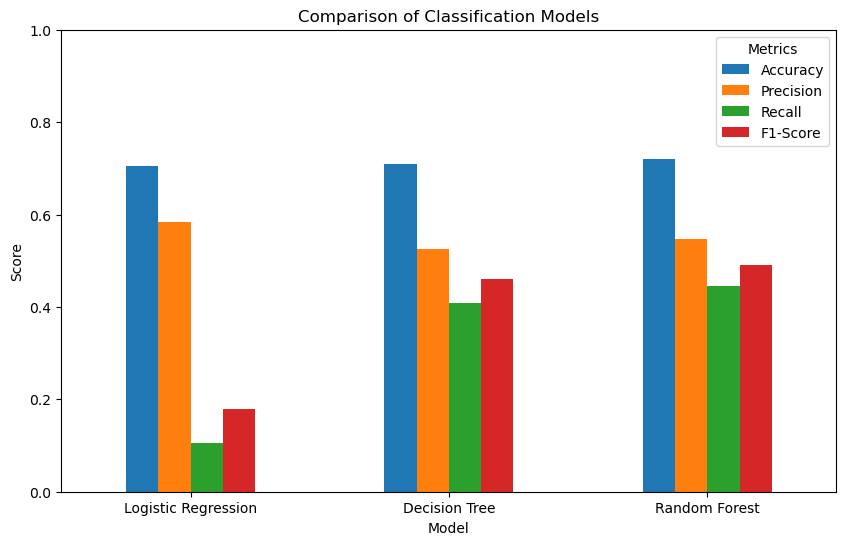

In [102]:
# Visualize Model Performance 
model_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

In [103]:
# Prepare dashboard data 
dashboard_type = df["type"].value_counts()

dashboard_country = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

dashboard_category = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

dashboard_rating = df["rating"].value_counts()

dashboard_added_year = df["added_year"].value_counts().sort_index()

print("Dashboard data prepared successfully.")

Dashboard data prepared successfully.


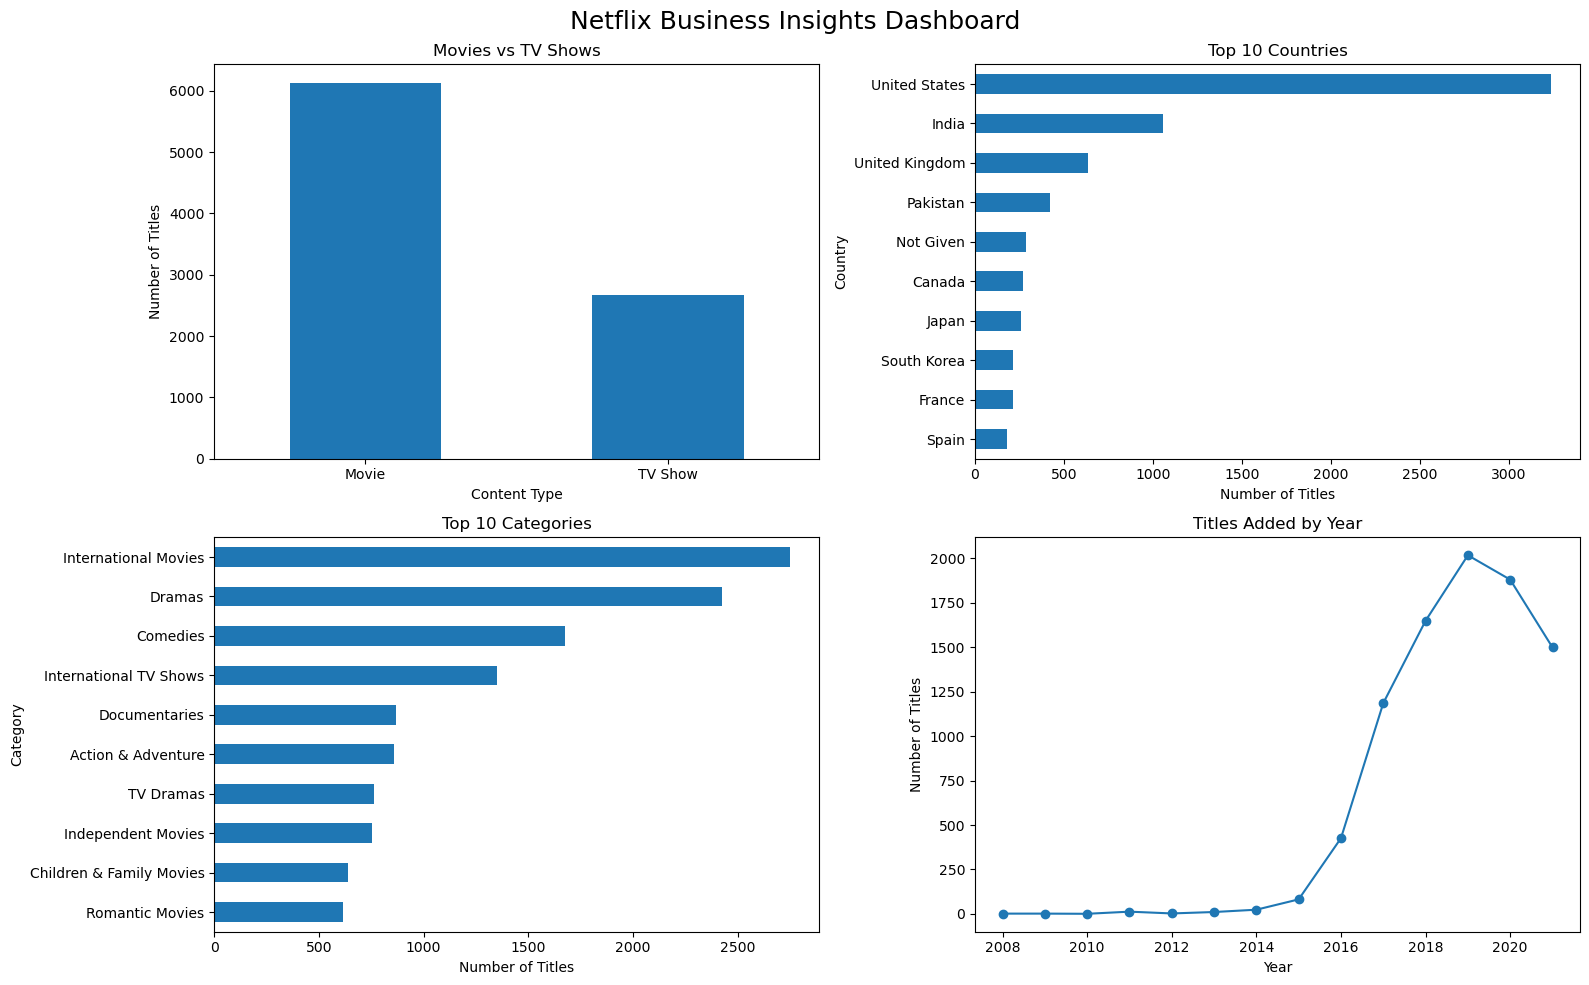

In [104]:
# Create the Dashboard 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Content Type
dashboard_type.plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Movies vs TV Shows")
axes[0, 0].set_xlabel("Content Type")
axes[0, 0].set_ylabel("Number of Titles")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Top Countries
dashboard_country.sort_values().plot(
    kind="barh",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Top 10 Countries")
axes[0, 1].set_xlabel("Number of Titles")
axes[0, 1].set_ylabel("Country")

# 3. Top Categories
dashboard_category.sort_values().plot(
    kind="barh",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Top 10 Categories")
axes[1, 0].set_xlabel("Number of Titles")
axes[1, 0].set_ylabel("Category")

# 4. Titles Added by Year
dashboard_added_year.plot(
    kind="line",
    marker="o",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Titles Added by Year")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Number of Titles")

plt.suptitle(
    "Netflix Business Insights Dashboard",
    fontsize=18
)

plt.tight_layout()
plt.show()

### Business Insights

1. **Movies dominate the Netflix dataset.**
   Movies account for approximately 70% of the titles, while TV Shows account for approximately 30%. This shows that the dataset has a stronger focus on movie content.

2. **International content is highly represented.**
   International Movies and International TV Shows are among the most common categories, indicating a strong presence of content from different countries and regions.

3. **Dramas and comedies are popular categories.**
   Dramas and Comedies appear among the most frequent categories, suggesting that these genres represent an important part of Netflix's content offering.

4. **Netflix content additions increased strongly over time.**
   The number of titles added increased significantly from the early years and reached its highest level around 2019, followed by a decline in later years.

5. **TV-MA and TV-14 are the most common ratings.**
   This indicates that a large proportion of the content in the dataset is intended for mature audiences and teenagers.

6. **Business implication:**
   Netflix's content strategy in this dataset shows a strong emphasis on movies, international content, dramas, and mature-rated programming. These patterns can help decision-makers understand content composition and identify areas for future content planning.


In [105]:
# Save the dashboard 
plt.savefig("Netflix_Business_Insights_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>